In [1]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles

In [7]:
function CompomenSpilit(vec,N)
    u = vec[1:N-1,1]
    v = vec[N:2N-2,1]
    w = vec[2N-1:3N-3,1]
    rho = vec[3N-2:4N-4,1]
    T = vec[4N-3:5N-5,1]
    
    u = [0;u;0]
    v = [0;v;0]
    w = [0;w;0]
    rho = [0;rho;0]
    T = [0;T;0]
    return u,v,w,rho,T
end

CompomenSpilit (generic function with 1 method)

In [ ]:
Ro = 1
Co = 2
N_cheb = 99
R = 400
be = 0.058
Mr = 0.2
Tw = 0.8
gamma = 1.4
sigma = 0.72
omega = 0.008
num = 1
Ma = Mr/R
c = 0.3
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T
A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol= 1e-10)

(ComplexF64[0.2867223224548124 - 0.03630659114467264im], ComplexF64[0.00019508734359590247 + 0.00014888292911288768im; 0.000790771092923884 + 0.0006051646709845202im; … ; 5.4364842262342254e-11 - 9.952873193387036e-12im; -2.0740113648337235e-11 + 3.2944320097498665e-12im;;], ComplexF64[0.03828301541158544 + 0.0im -0.00338092577442711 - 0.0015650761216474786im … 0.00017762158396618458 + 0.00010043928990676378im -0.002448948231974741 + 0.0008478981034930129im; -0.05709093712310842 + 0.0im 0.005841404513250119 + 0.003097647326852071im … -0.001474441565943302 + 0.0009630478382754927im 0.004569501510259357 - 0.0025964280821382207im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im])

In [53]:
eigval

1-element Vector{ComplexF64}:
 0.2867223224548124 - 0.03630659114467264im

In [54]:
u,v,w,rho,T = CompomenSpilit(eigvec,N_cheb)

(ComplexF64[0.0 + 0.0im, 0.00019508734359590247 + 0.00014888292911288768im, 0.000790771092923884 + 0.0006051646709845202im, 0.0017702643931243598 + 0.0013502646685213514im, 0.0031258790285423896 + 0.002368503466213898im, 0.004845995302787041 + 0.003648248828174866im, 0.0068962560439000155 + 0.005131187237686959im, 0.009280320037753058 + 0.006827822456321948im, 0.011928734440575194 + 0.008619755765539786im, 0.014868162749675451 + 0.010556697643113157im  …  1.818694198419627e-5 - 3.1670279143126284e-5im, -2.4445302860941296e-5 + 8.5198857789882e-6im, 2.164193746695318e-5 + 6.589014351376411e-6im, -1.3519756178834646e-5 - 6.793333144023816e-6im, 1.574356924900804e-6 - 1.3050638422966963e-5im, -8.72635080410893e-6 - 2.220379700981145e-5im, 8.957088459634883e-6 + 3.018641335579119e-5im, -5.401533569273106e-7 - 1.1335391354311275e-6im, 2.4398040457085423e-7 + 7.573837179945461e-7im, 0.0 + 0.0im], ComplexF64[0.0 + 0.0im, -0.00019117092243382523 - 0.00012007600319978987im, -0.00076343834624240

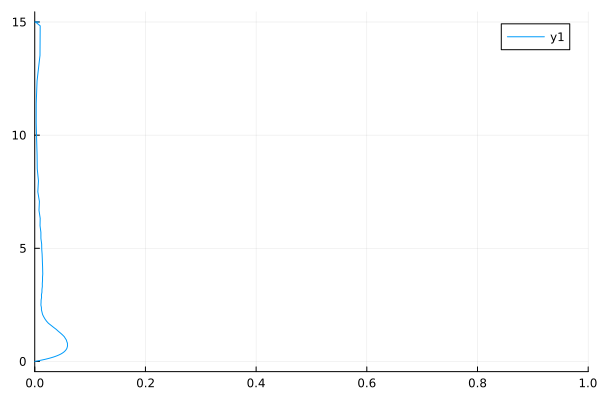

In [ ]:
plot(abs.(u),x,xlims=[0,1])